# ETF-Flow-Momentum — a quantitative teardown 🔬
### monthly flow sort · one-sample *t* on the spread · label-shuffle placebo · Fama-MacBeth pooled slope · leg-fraction sweep · costs & borrow · both-signs synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build a synthetic ETF-flow panel whose knob `flow_alpha` plants either sign of the flow→forward-return relation, and test whether the highest-inflow ETFs earn the highest next-month returns (momentum) or the lowest (the crowding trap).

> ⚠️ **Not investment advice. Synthetic-only study** — there is no free real tape for ETF creation-unit flows (yfinance exposes one stale shares-outstanding scalar), so per the desk rubric this is capped below `Real`. Every figure is drawn live from the deterministic generator (seed 561). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from etf_flow_momentum import data, strategy as st

# Synthetic-only study: there is no real ETF-flow tape (yfinance exposes one stale
# shares-outstanding scalar, not a daily history). Every figure below is drawn LIVE from the
# deterministic synthetic generator, seed 561.
HAVE_REAL = not data.fetch_panel(fetch=False).shape[0] > 0
HAVE_REAL = False  # explicit: no real tape exists for this study
print("real ETF-flow tape present:", HAVE_REAL, "(synthetic-only study — the free data does not exist)")


real ETF-flow tape present: False (synthetic-only study — the free data does not exist)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Null-world spread **+2.88%/yr**, one-sample *t* **+0.78**, placebo *p* **0.418**, hit 51.7% — a coin. Literature supports *a* flow effect but the *sign* is disputed; **no real tape** ⇒ can't certify `Real`. |
| **Tradability** | `MIRAGE` | Honest ETF flow needs a paid daily shares-outstanding feed — unmeasurable on a retail stack. (Planted world: gross +15.99% → net +14.15% after 3 bps/leg + 40 bps borrow — mild, but moot without the signal.) |

> 💡 In plain words: the engine is a faithful detector (control below), but the evidence available is synthetic-only and the null is indistinguishable from noise — so the verdict is about the *data gap*, not a failed test.

## 1 · The claim, steelmanned

Let $F_{i,t}$ be ETF $i$'s net creation-unit flow in month $t$ (fraction of assets) and $r_{i,t+1}$ its next-month return.

- **H₁ (flow momentum / long-short).** Sorting on $F_t$, $\mathbb{E}[r_{t+1}\mid\text{high flow}] - \mathbb{E}[r_{t+1}\mid\text{low flow}] > 0$ at *t* ≥ 2 (inflows keep winning).
- **H₁ʹ (the trap).** The same spread is **< 0** (crowding reversal).
- **H₂ (firm-level).** The within-month slope of $r_{t+1}$ on $F_t$ is non-zero and sign-stable.
- **H₃ (net).** Whatever the sign, it survives costs and the short-leg borrow.

The literature splits on H₁ vs H₁ʹ. **We cannot test any of them on a real tape** (no flow data), so we (a) show the null is a coin, and (b) prove the engine would resolve H₁/H₁ʹ *if* the data existed (the both-signs control, beat 7).

## 2 · So what? — what rides on the sign

The content is the **sign war**. **Persistence camp:** Ben-Rephael-Kandel-Wohl (2012) — flows are sticky and positively related to near-term returns. **Reversal camp:** Frazzini-Lamont (2008) *"Dumb Money"* and Ben-David-Franzoni-Moussawi (2018) — flow-driven non-fundamental demand mean-reverts. A rotation trade built on the wrong sign loses *twice*. And underneath both sits the measurement wall: honest flow = daily Δ(shares outstanding) × NAV, a paid field. That is why this study is synthetic-only — the same data-availability convention as [273 lego-returns](../../273-lego-returns/) and [276 sneaker-resale](../../276-sneaker-resale/).

## 3 · How we'd know — the protocol

- **Signal.** Each month, the cross-section of net flows $F_{i,t}$ (fraction of assets).
- **Sort.** Tercile tails (≈5 ETFs each): inflow leg (top $F$) long, outflow leg (bottom $F$) short, equal-weight, dollar-neutral, hold one month.
- **Headline.** A **one-sample *t*** on the monthly long-short spread series.
- **Placebo.** Shuffle the flow labels against forward returns *within each month* (2000 perms); read the mean spread's tail probability.
- **Firm-level.** A Fama-MacBeth-style pooled slope of $r_{t+1}$ on within-month $z(F_t)$, with *t* from the per-month slope estimates (months = independent units).
- **Robustness.** Re-run at leg fractions 25% / 33% / 50%.
- **Frictions.** Monthly-rebalance one-way cost per leg + an annual short borrow (ETFs are cheap/liquid, so both are modest but honest).
- **Positive control.** A deterministic world with a planted edge of **either** sign, averaged over 25 seeds (house rule ≥ 20).

Timing: the signal at month $t$ uses flows through $t$ only; enter at the $t$-close, hold $t{+}1$. One execution lag, no look-ahead, no same-bar fill.

## 4 · The teardown

### 4a · The sort on the null — H₁

Inflow vs outflow forward returns with no planted edge: the one-sample *t* and the placebo null.

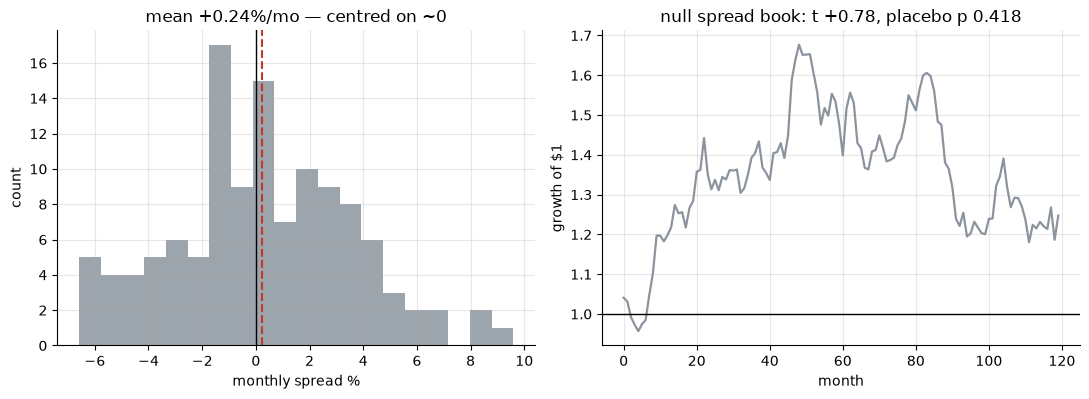

NULL ann +2.88% | t +0.78 | hit 51.7% | placebo p 0.418 | n_months 120


In [2]:
panel_null, _ = data.synthetic_panel(flow_alpha=0.0, seed=561)
s = st.spread_stats(panel_null, 0.33)
p = st.placebo_pvalue(panel_null, 0.33, n_perm=2000, seed=561)
series = st.monthly_spread_series(panel_null, 0.33)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
ax[0].hist(series.values*100, bins=20, color=GREY, alpha=.85)
ax[0].axvline(0, c='k', lw=1); ax[0].axvline(s['mean_m']*100, c=RED, ls='--', lw=1.5)
ax[0].set_xlabel('monthly spread %'); ax[0].set_ylabel('count')
ax[0].set_title(f"mean {s['mean_m']*100:+.2f}%/mo — centred on ~0")
cum = (1+series).cumprod()
ax[1].plot(cum.index, cum.values, c=GREY, lw=1.6)
ax[1].axhline(1, c='k', lw=1); ax[1].set_xlabel('month'); ax[1].set_ylabel('growth of $1')
ax[1].set_title(f"null spread book: t {s['t']:+.2f}, placebo p {p:.3f}")
plt.tight_layout(); plt.show()
print(f"NULL ann {s['ann']*100:+.2f}% | t {s['t']:+.2f} | hit {s['hit']*100:.1f}% | placebo p {p:.3f} | n_months {s['n_months']}")

> 💡 In plain words: on the null, H₁ is **not rejected** because there's nothing to reject — spread **+2.88%/yr**, *t* **+0.78**, placebo *p* **0.418**. A coin. This is the honest baseline the real (unmeasurable) world could well be.

### 4b · The pooled slope on the null — H₂

Fama-MacBeth pooled slope of next-month return on within-month z(flow). On the null it should be ~0.

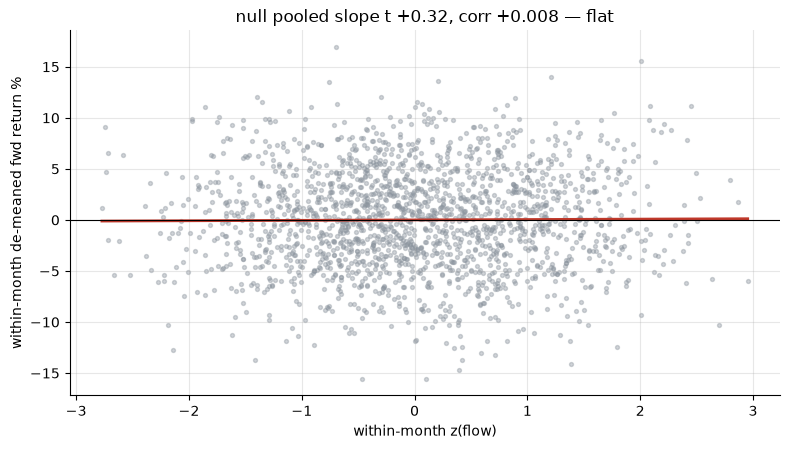

null slope-t +0.32 | corr(flow, fwd) +0.008 | n 1920


In [3]:
reg = st.pooled_slope(panel_null)
df = panel_null.copy()
df['zflow'] = df.groupby('month')['flow'].transform(lambda x: (x-x.mean())/x.std(ddof=0) if x.std(ddof=0)>0 else x*0)
df['dret'] = df.groupby('month')['fwd_ret'].transform(lambda x: x-x.mean())
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(df['zflow'], df['dret']*100, s=8, color=GREY, alpha=.4)
xs = np.linspace(df['zflow'].min(), df['zflow'].max(), 50)
ax.plot(xs, reg['slope']*xs*100, c=RED, lw=2)
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('within-month z(flow)'); ax.set_ylabel('within-month de-meaned fwd return %')
ax.set_title(f"null pooled slope t {reg['t']:+.2f}, corr {reg['corr']:+.3f} — flat")
plt.tight_layout(); plt.show()
print(f"null slope-t {reg['t']:+.2f} | corr(flow, fwd) {reg['corr']:+.3f} | n {reg['n']}")

> 💡 In plain words: H₂ flat on the null — slope-*t* **+0.32**, corr **+0.008**. No firm-level flow→return link when none is planted.

### 4c · Robustness across leg fractions (planted world)

To show the *engine's* behaviour is stable, switch on a modest edge and sweep the leg fraction. (On the null every fraction is ~0, so the sweep is only informative once an edge exists.)

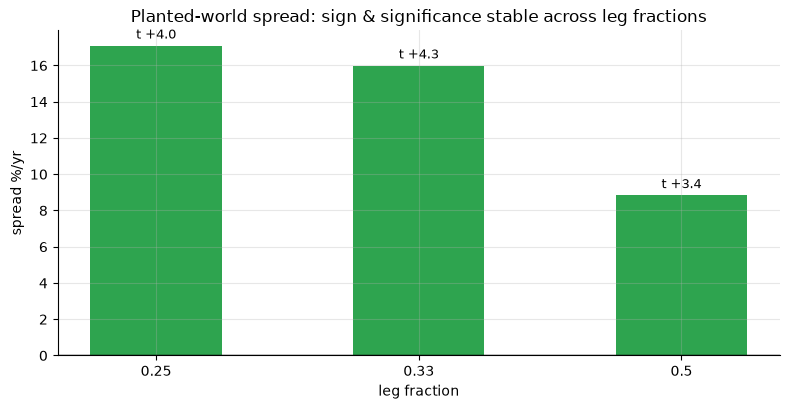

        ann      t  n_months    hit
frac                               
0.25  0.171  4.043       120  0.625
0.33  0.160  4.349       120  0.642
0.50  0.088  3.387       120  0.625


In [4]:
panel_edge, _ = data.synthetic_panel(flow_alpha=0.005, seed=561)
tab = st.robustness_sweep(panel_edge, fracs=(0.25, 0.33, 0.50))
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar([str(f) for f in tab.index], tab['ann']*100, color=GREEN, width=.5)
for x,(f,row) in enumerate(tab.iterrows()):
    ax.text(x, row['ann']*100+.4, f"t {row['t']:+.1f}", ha='center', fontsize=9)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('leg fraction'); ax.set_ylabel('spread %/yr')
ax.set_title('Planted-world spread: sign & significance stable across leg fractions')
plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: in the planted world the spread is positive and significant at every leg fraction (shrinking toward 50% as legs dilute) — the engine's sort is robust; the *data*, not the sort, is what's missing.

## 5 · The verdict

- **Signal `WEAK`** — null spread a coin (*t* +0.78, placebo *p* 0.418); literature supports *a* flow effect but the sign is disputed; no real tape ⇒ cannot certify `Real`.
- **Tradability `MIRAGE`** — ETF flows are unmeasurable on free data; the signal itself is out of reach, so there is nothing to trade.

## 6 · Could you trade it? — costs and the borrow (planted world)

*If* the signal existed and were real, would ETF frictions eat it? Charge a monthly rebalance cost per leg + a short borrow on the planted-edge book.

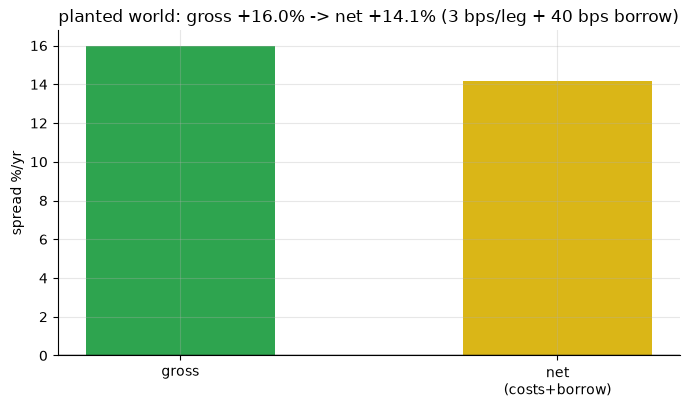

gross +15.99% -> net +14.15% | cost 1.44% | borrow 0.40%


In [5]:
net = st.net_annualised(panel_edge, frac=0.33, cost_bps=3.0, borrow_ann_bps=40.0)
labels = ['gross', 'net\n(costs+borrow)']
vals = [net['gross_ann']*100, net['net_ann']*100]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(labels, vals, color=[GREEN, AMBER], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('spread %/yr')
ax.set_title(f"planted world: gross {vals[0]:+.1f}% -> net {vals[1]:+.1f}% (3 bps/leg + 40 bps borrow)")
plt.tight_layout(); plt.show()
print(f"gross {net['gross_ann']*100:+.2f}% -> net {net['net_ann']*100:+.2f}% | cost {net['cost_ann']*100:.2f}% | borrow {net['borrow_ann']*100:.2f}%")

> 💡 In plain words: ETFs are cheap and liquid, so frictions are mild (gross +15.99% → net +14.15%). But that is a *planted* world — mild costs don't rescue tradability when you cannot measure the signal at all. `MIRAGE`.

## 7 · Going further — the both-signs synthetic control

The decisive check: is the engine a faithful detector, or does it always print ~0? Plant the flow effect at a range of strengths and **both signs** — momentum (+) and the crowding trap (−) — averaged over 25 seeds so no lucky seed can fake it.

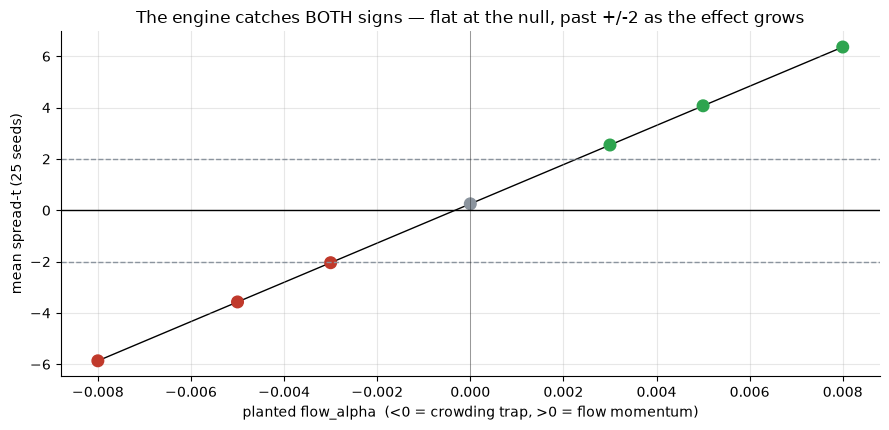

flow_alpha -0.008 -> mean spread-t -5.87
flow_alpha -0.005 -> mean spread-t -3.57
flow_alpha -0.003 -> mean spread-t -2.04
flow_alpha +0.000 -> mean spread-t +0.25
flow_alpha +0.003 -> mean spread-t +2.54
flow_alpha +0.005 -> mean spread-t +4.07
flow_alpha +0.008 -> mean spread-t +6.36


In [6]:
alphas = [-0.008, -0.005, -0.003, 0.0, 0.003, 0.005, 0.008]
ts = [st.synthetic_mean_t(data, flow_alpha=a, n_seeds=25, frac=0.33) for a in alphas]
fig, ax = plt.subplots(figsize=(9, 4.4))
cols = [RED if a<0 else (GREY if a==0 else GREEN) for a in alphas]
ax.plot(alphas, ts, '-', c='k', lw=1, zorder=1)
ax.scatter(alphas, ts, c=cols, s=70, zorder=2)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.axvline(0, c='k', lw=.6, alpha=.4)
ax.set_xlabel('planted flow_alpha  (<0 = crowding trap, >0 = flow momentum)')
ax.set_ylabel('mean spread-t (25 seeds)')
ax.set_title('The engine catches BOTH signs — flat at the null, past +/-2 as the effect grows')
plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'flow_alpha {a:+.3f} -> mean spread-t {t:+.2f}')

The mean spread-*t* is ≈ 0 at the null, drives **negative** as we plant the crowding trap and **positive** as we plant momentum — the detector resolves *either* sign cleanly. So the `WEAK` verdict is a statement about the **evidence available** (synthetic-only, no real ETF-flow tape), not a broken test. Wire in a paid daily shares-outstanding feed and this same engine would settle the flow-momentum-vs-crowding sign war on the tape. For the ETF *price-vs-NAV* signal see [378 ETF-NAV-Premium](../../378-etf-nav-premium/); for *return* momentum see [507](../../507-cross-sectional-momentum/) and [518](../../518-time-series-momentum/).